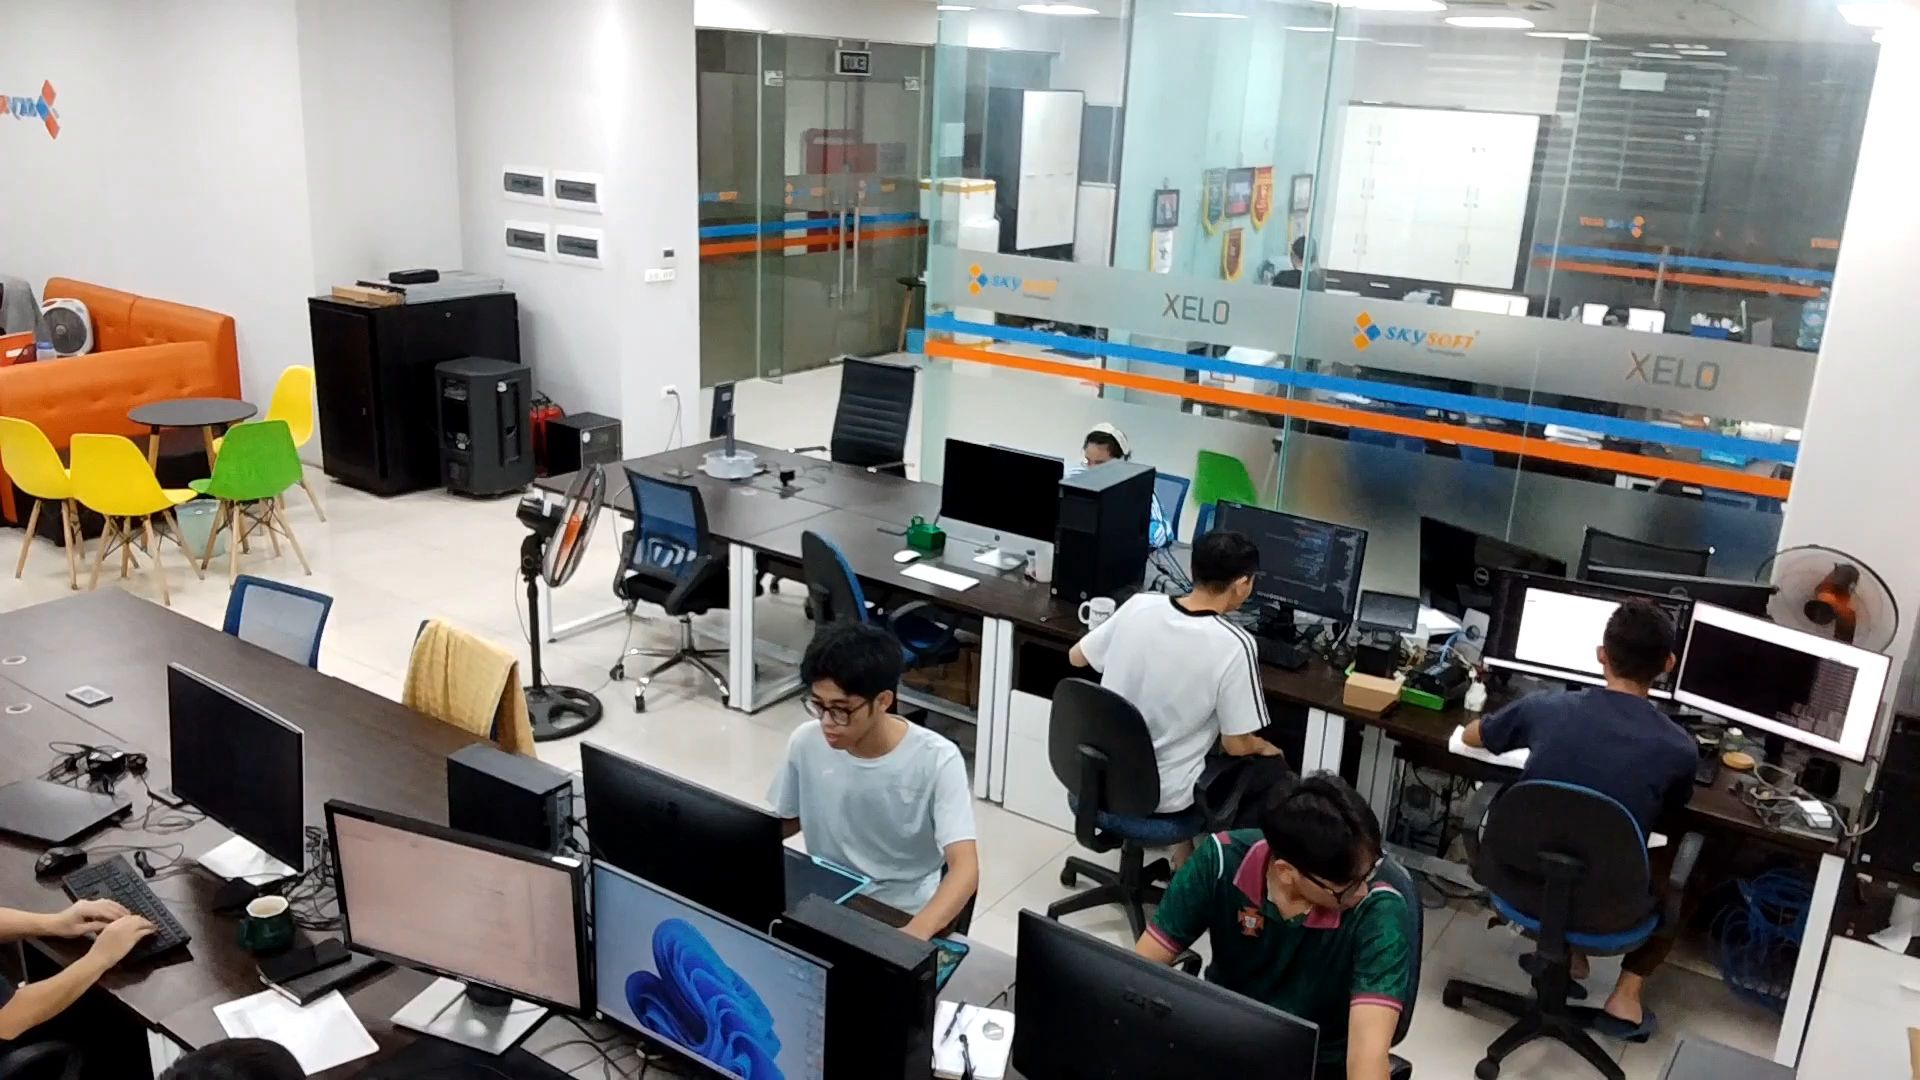

In [28]:
from IPython.display import Image
VIDEO_PATH = '../data/raw/1809.mp4'
IMAGE_PATH = '../data/raw/1809_frame.jpg'

Image(filename=IMAGE_PATH, width=400)

In [29]:
from ultralytics import YOLO
import cv2

In [30]:
import sys
import os

# Go up one directory level from 'notebooks/' to the project root
sys.path.append(os.path.abspath('..'))

# Now you can use absolute imports from the 'src' folder
from src.core.frame import Frame
from src.core.roi import ROI

In [31]:
model_1 = YOLO("../models/yolov8s.pt")
model_2 = YOLO("../models/yolov8s-pose.pt")
model_3 = YOLO("../models/head_detect.pt")
model_4 = YOLO("../models/pose_2909.pt")
model_5 = YOLO("../models/human-detect.pt")
# print(obj_model_1.names)
print(model_5.names)

# pose_model = YOLO("../models/yolov8n-pose.pt")

# seg_model = YOLO("../models/yolov8n-seg.pt")
# print(seg_model.names)

{0: 'person'}


In [32]:
results = model_2.predict(IMAGE_PATH, conf=0.3)

# 3. View and process the results
for result in results:
    result.show()  # Opens a window displaying the image with detected bounding boxes
    
    # Optional: Print detected bounding boxes, confidence scores, and class IDs
    print(result.boxes)



image 1/1 d:\Cuong\people_behavior\notebooks\..\data\raw\1809_frame.jpg: 384x640 4 persons, 120.1ms
Speed: 3.9ms preprocess, 120.1ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)
ultralytics.engine.results.Boxes object with attributes:

cls: tensor([0., 0., 0., 0.])
conf: tensor([0.9134, 0.8438, 0.8074, 0.8063])
data: tensor([[1.1307e+03, 7.7573e+02, 1.4239e+03, 1.0766e+03, 9.1341e-01, 0.0000e+00],
        [1.4494e+03, 5.9489e+02, 1.7007e+03, 1.0363e+03, 8.4376e-01, 0.0000e+00],
        [1.0659e+03, 5.2648e+02, 1.2944e+03, 8.3579e+02, 8.0736e-01, 0.0000e+00],
        [7.6586e+02, 6.2208e+02, 9.8122e+02, 9.5056e+02, 8.0627e-01, 0.0000e+00]])
id: None
is_track: False
orig_shape: (1080, 1920)
shape: torch.Size([4, 6])
xywh: tensor([[1277.2566,  926.1556,  293.1995,  300.8530],
        [1575.0493,  815.5896,  251.2721,  441.3997],
        [1180.1517,  681.1361,  228.5251,  309.3124],
        [ 873.5408,  786.3201,  215.3549,  328.4784]])
xywhn: tensor([[0.6652, 0.8576, 

In [ ]:
cap = cv2.VideoCapture(VIDEO_PATH)
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    # Process the frame here
    # Vẽ bbox và khung xương pose trên frame
    results = model_2.predict(frame, conf=0.3)
    for result in results:
        result.render()  # Draws the bounding boxes and pose skeleton on the frame
        

    cv2.imshow('Frame', frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break
cap.release()
cv2.destroyAllWindows()


0: 384x640 4 persons, 180.3ms
Speed: 6.1ms preprocess, 180.3ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)


AttributeError: 'Results' object has no attribute 'render'. See valid attributes below.
A class for storing and manipulating inference results.

    This class provides comprehensive functionality for handling inference results from various Ultralytics models,
    including detection, instance segmentation, semantic segmentation, depth estimation, classification, pose
    estimation, and oriented bounding box detection. It supports visualization, data export, and various coordinate
    transformations.

    Attributes:
        orig_img (np.ndarray): The original image as a numpy array.
        orig_shape (tuple[int, int]): Original image shape in (height, width) format.
        boxes (Boxes | None): Detected bounding boxes.
        masks (Masks | None): Segmentation masks.
        probs (Probs | None): Classification probabilities.
        keypoints (Keypoints | None): Detected keypoints.
        obb (OBB | None): Oriented bounding boxes.
        semantic_mask (SemanticMask | None): Se